In [ ]:
#bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import zipfile
import io

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#dataset baixar e extrair
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip"

r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

In [ ]:
#procurando o nome da pasta
import os
os.listdir()

['.config', 'CCPP', 'sample_data']

In [ ]:
os.listdir('CCPP')

['Readme.txt', 'Readme.txt~', 'Folds5x2_pp.xlsx', 'Folds5x2_pp.ods']

In [ ]:
#carregar dataset
df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

# Visualizar dados
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [ ]:
#questao 1 orrelação geral
corr = df.corr()

# Correlação com PE
corr_pe = corr['PE'].sort_values(ascending=False)
print(corr_pe)

PE    1.000000
AP    0.518429
RH    0.389794
V    -0.869780
AT   -0.948128
Name: PE, dtype: float64


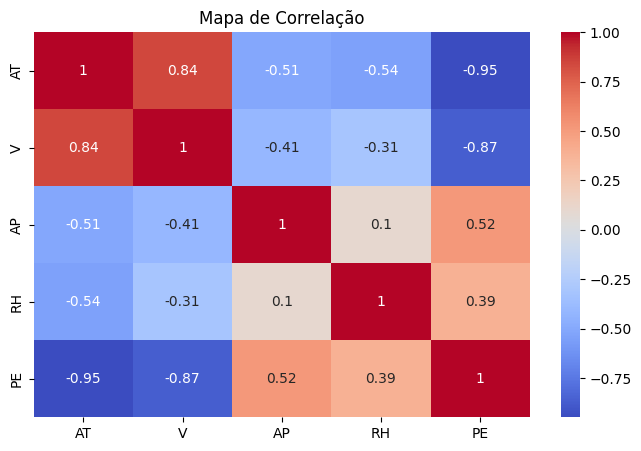

In [ ]:
#Visualização
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Mapa de Correlação")
plt.show()


In [ ]:
#2- Correlação entre variáveis independentes

corr_indep = df[['AT', 'V', 'AP', 'RH']].corr()
print(corr_indep)

          AT         V        AP        RH
AT  1.000000  0.844107 -0.507549 -0.542535
V   0.844107  1.000000 -0.413502 -0.312187
AP -0.507549 -0.413502  1.000000  0.099574
RH -0.542535 -0.312187  0.099574  1.000000


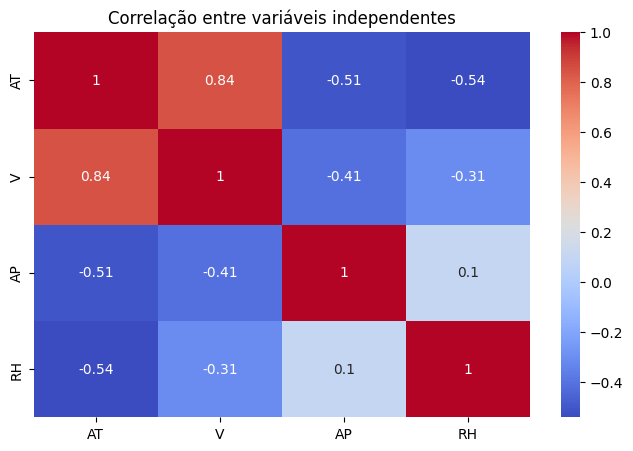

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(corr_indep, annot=True, cmap='coolwarm')
plt.title('Correlação entre variáveis independentes')
plt.show()

In [ ]:
#treino e teste questao 3
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#treinar modelo questao 3
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Intercepto:", modelo.intercept_)
print("Coeficientes:", modelo.coef_)

Intercepto: 454.56911458941477
Coeficientes: [-1.98589969 -0.23209358  0.06219991 -0.15811779]


In [ ]:
#previsoes questao 3
y_pred = modelo.predict(X_test)
print(y_pred)

[455.68020791 438.73212215 434.16444    ... 482.16817365 435.41524413
 458.76150613]


In [ ]:
#questão 4 Avaliar o modelo
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.9301046431962188
RMSE: 4.502633229532186
MAE: 3.595913178273408


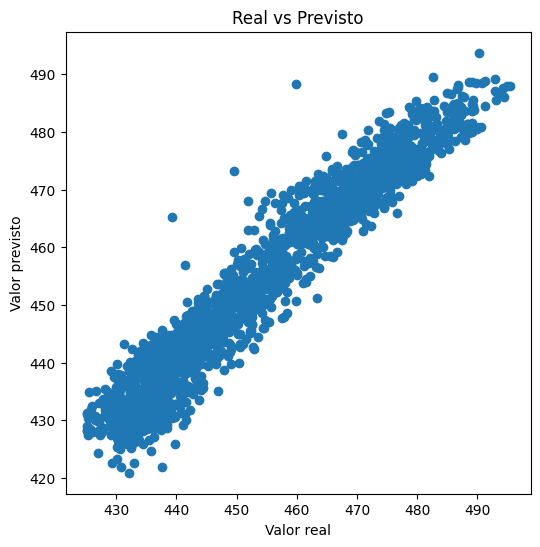

In [ ]:
#grafico de comparação
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Real vs Previsto")
plt.show()